Here we will train and optimize Graph Neural Networks (GNN) on the PDBind dataset. We will use data where affinities are evaluated in Kd vallues for couples of molecules and proteins, specifically those of the bigger group of the data set that represent a thousand couples of molecules with hydrolases. In order to have a better distribution of the kd values, we convert them in nM and compute their logarithm value.  

In [22]:
import pandas as pd
from preprocessing import PDBpreprocessing

raw_data = pd.read_csv("LP_PDBBind.csv")

preprocessed_data = PDBpreprocessing(raw_data, category= None, variable='both', keep_protein_chain=False, log_transform=True)
print(preprocessed_data.shape)
preprocessed_data.head()

(19121, 2)


,smiles,target
0,CSc1ccccc1[C@H]1CCCN1C(=O)CNC(=O)NCc1ccc2c(c1)...,1.796016
1,O=C([O-])CCC[N@H+]1CCC[C@H]1COc1ccc(Oc2ccc(Cl)...,3.223619
2,CCC(CC)O[C@@H]1C[C@H](C(=O)[O-])C[C@H]([NH3+])...,-1.473654
3,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,11.121486
4,[NH3+][C@@H](C[C@]1(C(=O)[O-])C[C@H]2OCC[C@@H]...,5.134765


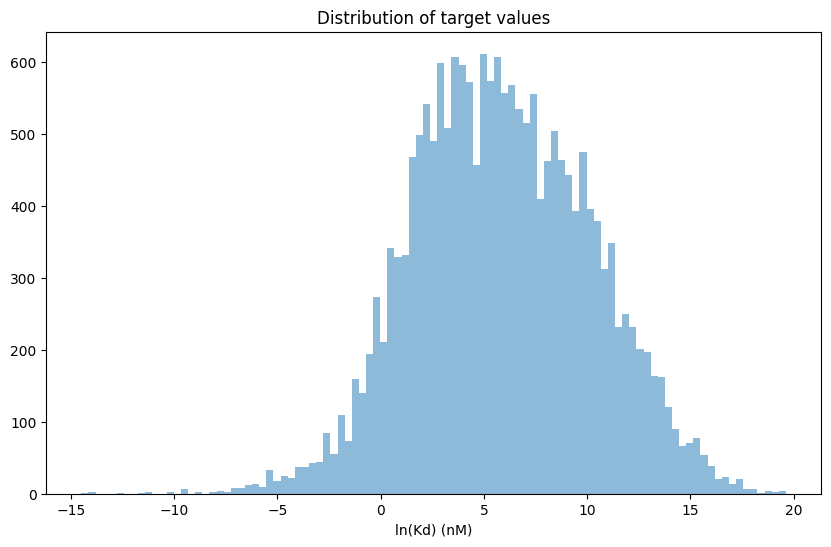

In [23]:
import numpy as np
X_plot = np.linspace(preprocessed_data['target'].min(), preprocessed_data['target'].max(), 100)
Y_plot = np.histogram(preprocessed_data['target'], bins=X_plot)[0]
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(X_plot[:-1], Y_plot, width=np.diff(X_plot), alpha=0.5)
plt.xlabel('ln(Kd) (nM)')
plt.title('Distribution of target values')
plt.show()

In [11]:
pip install 'numpy<2'

Note: you may need to restart the kernel to use updated packages.


Le fichier sp�cifi� est introuvable.


[14:56:51] Explicit valence for atom # 34 N, 4, is greater than permitted
[14:56:51] Unusual charge on atom 1 number of radical electrons set to zero
[14:56:51] Unusual charge on atom 2 number of radical electrons set to zero
[14:56:51] Unusual charge on atom 2 number of radical electrons set to zero
[14:56:51] Unusual charge on atom 36 number of radical electrons set to zero
[14:56:51] Unusual charge on atom 36 number of radical electrons set to zero
[14:56:52] Unusual charge on atom 12 number of radical electrons set to zero
[14:56:52] Unusual charge on atom 12 number of radical electrons set to zero
[14:56:53] Unusual charge on atom 16 number of radical electrons set to zero
[14:56:53] Explicit valence for atom # 3 N, 4, is greater than permitted
[14:56:53] Unusual charge on atom 16 number of radical electrons set to zero
[14:56:53] Explicit valence for atom # 3 N, 4, is greater than permitted
[14:56:53] Explicit valence for atom # 7 Cl, 3, is greater than permitted
[14:56:53] Expli

Converted 19115 molecules to PyG graph objects
hidden=6 lr=1e-05 batch=32 epochs=64 -> mse=18.2239 r2=0.0062
hidden=6 lr=1e-05 batch=32 epochs=64 -> mse=18.2239 r2=0.0062
hidden=6 lr=1e-05 batch=32 epochs=128 -> mse=18.3839 r2=-0.0026
hidden=6 lr=1e-05 batch=32 epochs=128 -> mse=18.3839 r2=-0.0026
hidden=6 lr=1e-05 batch=64 epochs=64 -> mse=18.6648 r2=-0.0179
hidden=6 lr=1e-05 batch=64 epochs=64 -> mse=18.6648 r2=-0.0179
hidden=6 lr=1e-05 batch=64 epochs=128 -> mse=18.3300 r2=0.0004
hidden=6 lr=1e-05 batch=64 epochs=128 -> mse=18.3300 r2=0.0004
hidden=12 lr=1e-05 batch=32 epochs=64 -> mse=18.1219 r2=0.0117
hidden=12 lr=1e-05 batch=32 epochs=64 -> mse=18.1219 r2=0.0117
hidden=12 lr=1e-05 batch=32 epochs=128 -> mse=18.1364 r2=0.0109
hidden=12 lr=1e-05 batch=32 epochs=128 -> mse=18.1364 r2=0.0109
hidden=12 lr=1e-05 batch=64 epochs=64 -> mse=18.4051 r2=-0.0037
hidden=12 lr=1e-05 batch=64 epochs=64 -> mse=18.4051 r2=-0.0037
hidden=12 lr=1e-05 batch=64 epochs=128 -> mse=18.0038 r2=0.0182
hid

,hidden,lr,batch_size,epochs,mse,r2
7,12,0.00001,64,128,18.003836,0.018170
4,12,0.00001,32,64,18.121874,0.011733
5,12,0.00001,32,128,18.136353,0.010944
0,6,0.00001,32,64,18.223898,0.006170
3,6,0.00001,64,128,18.329950,0.000386
1,6,0.00001,32,128,18.383934,-0.002558
6,12,0.00001,64,64,18.405096,-0.003712
2,6,0.00001,64,64,18.664768,-0.017873


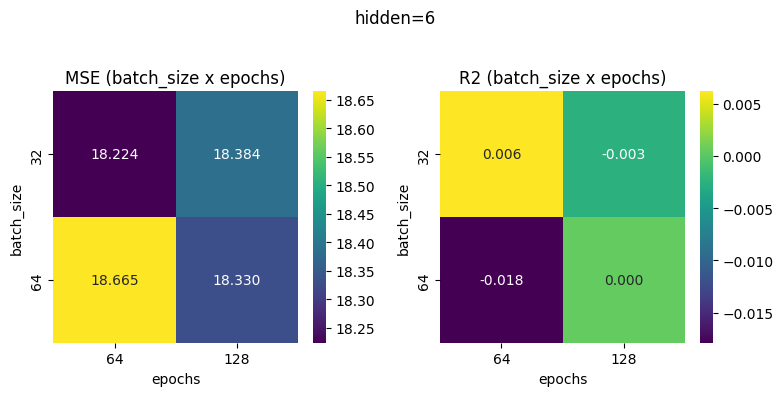

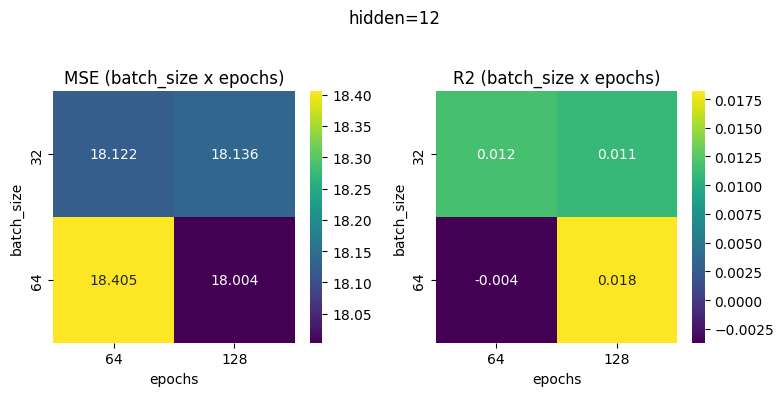


Best hyperparameters (min MSE):
{'hidden': 12.0, 'lr': 1e-05, 'batch_size': 64.0, 'epochs': 128.0, 'mse': 18.003835678100586, 'r2': 0.018170475959777832}


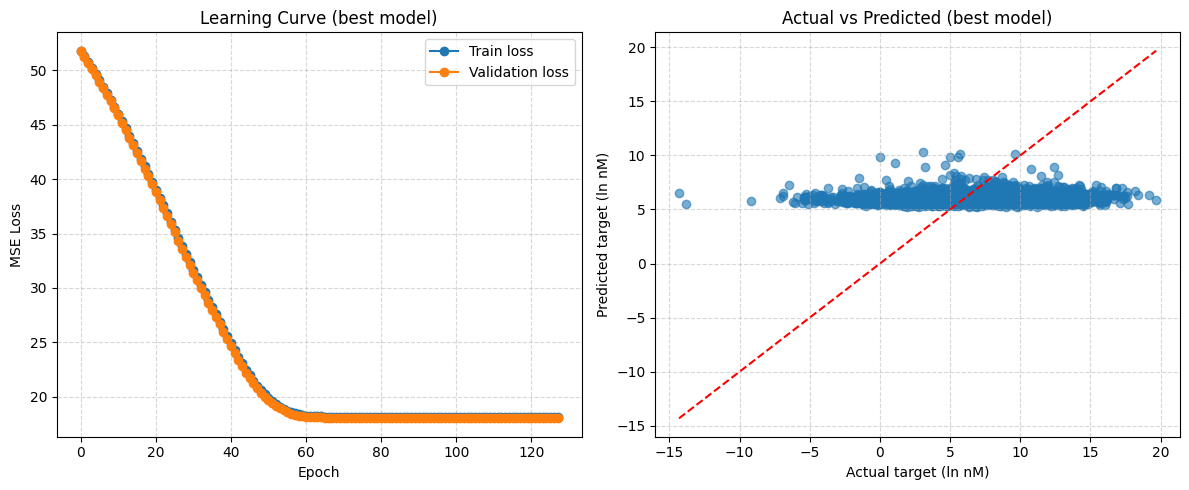

In [24]:
# GNN training + hyperparameter grid (PyG preferred, RDKit-based GNN fallback)
# Hyperparameters to sweep (exactly as requested)
hidden_dims = [6, 12]
lrs = [1e-5]
batch_sizes = [32, 64]
epochs_list = [64, 128]

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from ogb.utils import smiles2graph

results = []
results.clear()
best = None
best_mse = float('inf')


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def smiles_to_data_pyg(smi, y):
    g = smiles2graph(smi)
    x = torch.tensor(g['node_feat'], dtype=torch.float)
    edge_index = torch.tensor(g['edge_index'], dtype=torch.long)
    if edge_index.dim() == 1:
        edge_index = edge_index.view(2, -1)
    data = Data(x=x, edge_index=edge_index)
    data.y = torch.tensor([y], dtype=torch.float)
    return data

smiles = preprocessed_data['smiles'].tolist()
targets = preprocessed_data['target'].astype(float).tolist()
data_list = []
for s, t in zip(smiles, targets):
    try:
        data_list.append(smiles_to_data_pyg(s, t))
    except Exception:
        continue
print(f'Converted {len(data_list)} molecules to PyG graph objects')
if len(data_list) == 0:
    raise RuntimeError('No molecules converted to graphs (PyG path)')

train_idx, test_idx = train_test_split(range(len(data_list)), test_size=0.2, random_state=42)
def make_loader(idxs, batch_size):
    subset = [data_list[i] for i in idxs]
    return DataLoader(subset, batch_size=batch_size, shuffle=True)

class SimpleGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim=1):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = torch.nn.Linear(hidden_dim, out_dim)
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).view(-1)

in_dim = data_list[0].x.shape[1]

# grid search over requested hyperparameters
for hidden in hidden_dims:
    for lr in lrs:
        for batch_size in batch_sizes:
            for epochs in epochs_list:
                train_loader = make_loader(train_idx, batch_size)
                test_loader = make_loader(test_idx, batch_size)
                model = SimpleGNN(in_dim, hidden).to(device)
                opt = torch.optim.Adam(model.parameters(), lr=lr)
                loss_fn = torch.nn.MSELoss()
                train_losses = []
                val_losses = []
                # training loop for the chosen number of epochs
                for ep in range(epochs):
                    model.train()
                    train_loss_epoch = 0.0
                    for batch in train_loader:
                        batch = batch.to(device)
                        opt.zero_grad()
                        out = model(batch)
                        loss = loss_fn(out, batch.y.view(-1))
                        loss.backward()
                        opt.step()
                        train_loss_epoch += loss.item() * batch.num_graphs
                    train_losses.append(train_loss_epoch / len(train_loader.dataset))

                    # validation loss
                    model.eval()
                    val_loss_epoch = 0.0
                    with torch.no_grad():
                        for batch in test_loader:
                            batch = batch.to(device)
                            out = model(batch)
                            val_loss_epoch += loss_fn(out, batch.y.view(-1)).item() * batch.num_graphs
                    val_losses.append(val_loss_epoch / len(test_loader.dataset))

                # evaluation
                model.eval()
                ys, ypreds = [], []
                with torch.no_grad():
                    for batch in test_loader:
                        batch = batch.to(device)
                        out = model(batch)
                        ys.append(batch.y.view(-1).cpu().numpy())
                        ypreds.append(out.cpu().numpy())
                ys = np.concatenate(ys) if len(ys)>0 else np.array([])
                ypreds = np.concatenate(ypreds) if len(ypreds)>0 else np.array([])
                if ys.size == 0:
                    continue
                mse = mean_squared_error(ys, ypreds)
                r2 = r2_score(ys, ypreds)
                results.append({'hidden':hidden, 'lr':lr, 'batch_size':batch_size, 'epochs':epochs, 'mse':mse, 'r2':r2})
                if mse < best_mse:
                    best_mse = mse
                    best = {'model': model, 'hidden':hidden, 'lr':lr, 'batch_size':batch_size, 'epochs':epochs, 'mse':mse, 'r2':r2, 'test_y': ys, 'test_pred': ypreds,'train_losses': train_losses,'val_losses': val_losses}
                print(f'hidden={hidden} lr={lr} batch={batch_size} epochs={epochs} -> mse={mse:.4f} r2={r2:.4f}')

# Summarize results and plot heatmaps (batch_size x epochs) for each hidden_dim
try:
    df_res = pd.DataFrame(results)
    if df_res.empty:
        print('No results collected from GNN runs')
    else:
        display(df_res.sort_values('mse').head(10))
        import seaborn as sns
        for hidden in sorted(df_res['hidden'].unique()):
            sub = df_res[df_res['hidden'] == hidden]
            pivot_mse = sub.pivot_table(index='batch_size', columns='epochs', values='mse')
            pivot_r2 = sub.pivot_table(index='batch_size', columns='epochs', values='r2')

            plt.figure(figsize=(8,4))
            plt.suptitle(f'hidden={hidden}')
            plt.subplot(1,2,1)
            sns.heatmap(pivot_mse, annot=True, fmt='.3f', cmap='viridis')
            plt.title('MSE (batch_size x epochs)')

            plt.subplot(1,2,2)
            sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='viridis')
            plt.title('R2 (batch_size x epochs)')
            plt.tight_layout(rect=[0,0,1,0.95])
            plt.show()

        # print best hyperparameters and metrics
        best_idx = df_res['mse'].idxmin()
        best_row = df_res.loc[best_idx]
        print('\nBest hyperparameters (min MSE):')
        print(best_row.to_dict())

        # plot Actual vs Predicted for best
        if best is not None and 'test_y' in best and 'test_pred' in best:
            ys = np.array(best['test_y'])
            ypreds = np.array(best['test_pred'])
            plt.figure(figsize=(12,5))

            # --- Left: Learning curve ---
            plt.subplot(1,2,1)
            plt.plot(best['train_losses'], label='Train loss', marker='o')
            plt.plot(best['val_losses'], label='Validation loss', marker='o')
            plt.xlabel('Epoch')
            plt.ylabel('MSE Loss')
            plt.title('Learning Curve (best model)')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)

            # --- Right: Actual vs Predicted ---
            plt.subplot(1,2,2)
            plt.scatter(ys, ypreds, alpha=0.6)
            mn = min(ys.min(), ypreds.min())
            mx = max(ys.max(), ypreds.max())
            plt.plot([mn,mx],[mn,mx], color='red', linestyle='--')
            plt.xlabel('Actual target (ln nM)')
            plt.ylabel('Predicted target (ln nM)')
            plt.title('Actual vs Predicted (best model)')
            plt.grid(True, linestyle='--', alpha=0.5)

            plt.tight_layout()
            plt.show()

        else:
            print('Best model/predictions missing; cannot plot Actual vs Predicted')
except Exception as e:
    print('Could not summarize/plot results:', e)


+ Learning curve test/validation before optimization